In [1]:
import timm
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import gc

/home/tts26/miniconda3/envs/trinhnc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import csv
import random
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import copy
from tqdm import tqdm
import time
import random
from torch.amp import autocast
import torch.nn.functional as F
from PIL import Image

In [3]:
import os
import sys

root_path = os.path.abspath(os.path.join(os.getcwd(), "../"))

if root_path not in sys.path:
    sys.path.append(root_path)

# DroneCVGL Embedding Visualization

This notebook visualizes feature embeddings and retrieval results from the DroneCVGL models.

**Workflow:**
1. Load configuration and model from checkpoint
2. Load evaluation datasets and transforms
3. Load pre-computed retrieval results (run `eval_and_get_topk.py` first)
4. Visualize feature heatmaps for sample images
5. Visualize retrieval grids showing top-k matches

In [4]:
from data.sues200 import SUES200DatasetEval, get_transforms
from core.metrics.sues200 import compute_mAP
from utils.registry import build_model
from utils.predict import ForwardMode

from models.siamese_network import SiameseNetwork
from models.siamese_network_max_avg import SiameseNetworkMaxAvg
from models.asymmetric_network import AsymmetricNetwork
from models.sinkhorn_siamese_network import SinkhornSiameseNetwork
from core.loss import InfoNCE

## Prerequisites

Before running this notebook, ensure:
1. Model checkpoint is available at the path specified in `config.training.checkpoint_start`
2. Evaluation dataset (SUES-200) is available in `./data/SUES-200-512x512/`
3. Run `eval_and_get_topk.py` to generate retrieval results CSV file

The notebook uses the configuration from `config/sinkhorn_siamese.yaml` by default. Modify the `config_path` below to use a different configuration.

In [5]:
from omegaconf import OmegaConf

# Load configuration from YAML
script_dir = os.path.dirname(os.path.abspath(os.getcwd()))
config_path = os.path.join(script_dir, "config", "base.yaml")
config = OmegaConf.load(config_path)

# Build model using registry
model = build_model(config)
model_data_config = model.get_config()

# Get normalization parameters
query_mean = model_data_config['query']['mean']
query_std = model_data_config['query']['std']
query_img_size = (config.data.drone_img_size, config.data.drone_img_size)

print("Model:", config.model.model_name)
print("Device:", 'cuda' if torch.cuda.is_available() else 'cpu')

Model: SiameseNetworkMaxAvg
Device: cuda


In [6]:
# Setup device and configuration
os.environ["CUDA_VISIBLE_DEVICES"] = "6"
config.training.device = 'cuda' if torch.cuda.is_available() else 'cpu'
if os.name == 'nt':
    config.training.num_workers = 0

print("="*60)
print("Experiment Config")
print(OmegaConf.to_yaml(config))
print("="*60)

Experiment Config
logging:
  project_name: Drone CVGL
  task_name: Train HGNetv2
model:
  model_path: ./university_checkpoint
  model_name: SiameseNetworkMaxAvg
  model_args:
    model_name: hgnetv2_b1.ssld_stage1_in22k_in1k
    pretrained: true
    img_size: 384
loss:
  loss_name: InfoNCE
  loss_args:
    label_smoothing: 0.1
data:
  img_size: 384
  sat_img_size:
  - 384
  - 384
  drone_img_size:
  - 384
  - 384
  dataset: U1652-D2S
  data_folder: ./data/University-Release
eval:
  batch_size_eval: 32
  eval_every_n_epoch: 1
  normalize_features: true
  eval_reference_n: -1
training:
  mixed_precision: false
  custom_sampling: true
  seed: 1
  epochs: 20
  batch_size: 32
  verbose: true
  gpu_ids:
  - 0
  sim_sample: false
  clip_grad: 100
  decay_exclude_bias: false
  grad_checkpointing: false
  lr: 0.0001
  scheduler: cosine
  warmup_epochs: 1
  lr_end: 0.0001
  prob_flip: 0.5
  zero_shot: false
  checkpoint_start: /home/tts26/sonh/university_checkpoint/SiameseNetworkMaxAvg/20260408_

In [7]:
# Load checkpoint if available
if config.training.checkpoint_start is not None:
    print("Loading checkpoint:", config.training.checkpoint_start)
    ckpt = torch.load(config.training.checkpoint_start, map_location='cpu')
    state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
    model.load_state_dict(state_dict, strict=False)
else:
    print("No checkpoint specified, using pretrained weights")

# Handle DataParallel if multiple GPUs
if torch.cuda.device_count() > 1 and len(config.training.gpu_ids) > 1:
    model = torch.nn.DataParallel(model, device_ids=config.training.gpu_ids)

model = model.to(config.training.device)
model.eval()

Loading checkpoint: /home/tts26/sonh/university_checkpoint/SiameseNetworkMaxAvg/20260408_085404/weights_end.pth


/tmp/ipykernel_2987315/1271819704.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(config.training.checkpoint_start, map_location='cpu')


SiameseNetworkMaxAvg(
  (model): HighPerfGpuNet(
    (stem): StemV2(
      (stem1): ConvBNAct(
        (conv): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU()
        (lab): LearnableAffineBlock()
      )
      (stem2a): ConvBNAct(
        (conv): Conv2d(24, 12, kernel_size=(2, 2), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU()
        (lab): LearnableAffineBlock()
      )
      (stem2b): ConvBNAct(
        (conv): Conv2d(12, 24, kernel_size=(2, 2), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU()
        (lab): LearnableAffineBlock()
      )
      (stem3): ConvBNAct(
        (conv): Conv2d(48, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=Fal

In [8]:
# Load transforms
val_transforms, train_sat_transforms, train_drone_transforms = get_transforms(
    img_size=query_img_size[0],
    mean=query_mean,
    std=query_std
)

In [9]:
def predict_feature_heatmap(model, img_tensor):
    model.eval()
    with torch.no_grad():
        # The model now directly returns the final feature map
        # Keep mode=ForwardMode.QUERY if your architecture specifically requires it
        features = model(img_tensor, mode=ForwardMode.QUERY)
        
    # Remove the batch dimension. Assuming shape is [1, Channels, Height, Width]
    feat = features.squeeze(0)
    
    # Optional safety check: If the output is a 1D vector, this method won't work
    if feat.dim() == 1:
        raise ValueError("Model output is a 1D vector (likely after pooling). Spatial heatmaps require 2D/3D feature maps [C, H, W].")

    # Average across all channels to create a single 2D heatmap
    heatmap = feat.mean(0).cpu().numpy()
    
    # Normalize heatmap to range [0, 1] to avoid division by zero
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    
    # Extract the spatial dimensions (Height, Width) from the tensor
    target_shape = img_tensor.shape[-2:]
    
    return heatmap, target_shape


def visualize_heatmap(original_image, heatmap, target_shape, alpha=0.5, cmap='jet'):
    tensor_h, tensor_w = target_shape
    
    img_resized = cv2.resize(original_image.copy(), (tensor_w, tensor_h))
    img_np = np.array(img_resized) / 255.0

    heatmap_up = cv2.resize(heatmap, (tensor_w, tensor_h))
    
    colormap = plt.get_cmap(cmap)
    heatmap_color = colormap(heatmap_up)[..., :3]

    # Create the overlay
    overlay = alpha * img_np + (1.0 - alpha) * heatmap_color

    # Plot the results
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img_resized)
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_up, cmap=cmap)
    plt.title("Heatmap (Final Feature)")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


def visualize_retrieval_grid(model, image_paths, preprocess_fn, root_path="../../", num_cols=5, include_gt=True, alpha=0.5, cmap='jet', show_heatmap=True):
    """
    Visualizes image retrieval results.
    Set `show_heatmap=False` to skip heatmap generation and only plot the original images.
    """
    # Ensure we don't try to plot more columns than we have image paths (excluding GT)
    max_available_cols = len(image_paths) - 1
    num_cols = min(num_cols, max_available_cols)
    
    # Store the exact indices of the images we want to pull from the list
    idx_cols = list(range(num_cols))
    if include_gt:
        idx_cols.append(len(image_paths) - 1)
    
    # Calculate the total number of columns to draw in the plot
    total_plot_cols = len(idx_cols)
    
    # Determine the number of rows based on the heatmap toggle
    nrows = 3 if show_heatmap else 1
    
    # Create a figure with dynamic row counts
    fig, axes = plt.subplots(nrows=nrows, ncols=total_plot_cols, figsize=(4 * total_plot_cols, 3.5 * nrows))
    
    # Standardize axes to always be a 2D array [row, col] for safe indexing
    if not isinstance(axes, np.ndarray):
        axes = np.array([[axes]])
    elif axes.ndim == 1:
        if nrows == 1:
            axes = axes[np.newaxis, :]  # 1 row, multiple cols
        else:
            axes = axes[:, np.newaxis]  # multiple rows, 1 col

    for plot_col, data_idx in enumerate(idx_cols):
        img_path = image_paths[data_idx]
        
        # 1. Load the original image
        if os.path.isabs(img_path):
            full_image_path = img_path
        else:
            full_image_path = os.path.join(root_path, img_path)
        
        orig_img = cv2.imread(full_image_path)
        if orig_img is None:
            print(f"Warning: Could not load image at {full_image_path}")
            continue
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        
        # Titles logic
        if plot_col == 0:
            title_prefix = "Query"
        elif include_gt and plot_col == total_plot_cols - 1:
            title_prefix = "Ground Truth"
        else:
            title_prefix = f"Rank {plot_col}"
        
        if show_heatmap:
            # 2. Preprocess the image
            augmented = preprocess_fn(image=orig_img)
            img_tensor = augmented["image"].unsqueeze(0).to(next(model.parameters()).device)        
            
            # 3. Predict heatmap
            heatmap, target_shape = predict_feature_heatmap(model, img_tensor)
            
            # 4. Prepare visualizations
            tensor_h, tensor_w = target_shape
            img_resized = cv2.resize(orig_img, (tensor_w, tensor_h))
            img_np = np.array(img_resized) / 255.0
            
            heatmap_up = cv2.resize(heatmap, (tensor_w, tensor_h))
            colormap = plt.get_cmap(cmap)
            heatmap_color = colormap(heatmap_up)[..., :3]
            
            overlay = alpha * img_np + (1.0 - alpha) * heatmap_color
            
            # Row 0: Original Image
            axes[0, plot_col].imshow(img_resized)
            axes[0, plot_col].axis('off')
            axes[0, plot_col].set_title(f"{title_prefix}\n(Original)", fontsize=20)
                
            # Row 1: Heatmap
            axes[1, plot_col].imshow(heatmap_up, cmap=cmap)
            axes[1, plot_col].axis('off')
            if plot_col == 0:
                axes[1, plot_col].set_title("Heatmap", fontsize=20)
            
            # Row 2: Overlay
            axes[2, plot_col].imshow(overlay)
            axes[2, plot_col].axis('off')
            if plot_col == 0:
                axes[2, plot_col].set_title("Overlay", fontsize=20)
        else:
            # Bypass model inference entirely and only plot the original loaded images
            axes[0, plot_col].imshow(orig_img)
            axes[0, plot_col].axis('off')
            axes[0, plot_col].set_title(title_prefix, fontsize=20)

    plt.tight_layout()
    plt.show()

def visualize_retrieval_grid_batch(model, batch_image_paths, preprocess_fn, root_path="../../", num_cols=5, include_gt=True, alpha=0.5, cmap='jet', show_heatmap=True):
    """
    Visualizes image retrieval results for a batch of queries.
    `batch_image_paths` should be a list of lists, where each sublist contains 
    the query image, retrieved images, and optionally the ground truth.
    """
    num_queries = len(batch_image_paths)
    if num_queries == 0:
        print("No image paths provided.")
        return

    # Use the first query to determine the column structure
    max_available_cols = len(batch_image_paths[0]) - 1
    actual_num_cols = min(num_cols, max_available_cols)
    
    # Store the exact indices of the images we want to pull from each sublist
    idx_cols = list(range(actual_num_cols))
    if include_gt:
        idx_cols.append(len(batch_image_paths[0]) - 1)
    
    total_plot_cols = len(idx_cols)
    
    # Determine the number of rows per query, then calculate total rows
    nrows_per_query = 3 if show_heatmap else 1
    total_rows = num_queries * nrows_per_query
    
    # Create a dynamic figure
    fig, axes = plt.subplots(nrows=total_rows, ncols=total_plot_cols, figsize=(4 * total_plot_cols, 3.5 * total_rows))
    
    # Standardize axes to always be a 2D array [row, col] for safe indexing
    if not isinstance(axes, np.ndarray):
        axes = np.array([[axes]])
    elif axes.ndim == 1:
        if total_rows == 1:
            axes = axes[np.newaxis, :]
        else:
            axes = axes[:, np.newaxis]

    for q_idx, image_paths in enumerate(batch_image_paths):
        row_offset = q_idx * nrows_per_query
        
        for plot_col, data_idx in enumerate(idx_cols):
            # Safety check in case sublists have different lengths
            if data_idx >= len(image_paths):
                continue
                
            img_path = image_paths[data_idx]
            
            # 1. Load the original image
            if os.path.isabs(img_path):
                full_image_path = img_path
            else:
                full_image_path = os.path.join(root_path, img_path)
            
            orig_img = cv2.imread(full_image_path)
            if orig_img is None:
                print(f"Warning: Could not load image at {full_image_path}")
                continue
            orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
            
            # Titles logic (Keep titles clean for multi-row displays)
            if plot_col == 0:
                title_prefix = f"Q{q_idx + 1} Query"
            elif include_gt and plot_col == total_plot_cols - 1:
                title_prefix = "Ground Truth"
            else:
                title_prefix = f"Rank {plot_col}"
            
            if show_heatmap:
                # 2. Preprocess the image
                augmented = preprocess_fn(image=orig_img)
                img_tensor = augmented["image"].unsqueeze(0).to(next(model.parameters()).device)        
                
                # 3. Predict heatmap
                heatmap, target_shape = predict_feature_heatmap(model, img_tensor)
                
                # 4. Prepare visualizations
                tensor_h, tensor_w = target_shape
                img_resized = cv2.resize(orig_img, (tensor_w, tensor_h))
                img_np = np.array(img_resized) / 255.0
                
                heatmap_up = cv2.resize(heatmap, (tensor_w, tensor_h))
                colormap = plt.get_cmap(cmap)
                heatmap_color = colormap(heatmap_up)[..., :3]
                
                overlay = alpha * img_np + (1.0 - alpha) * heatmap_color
                
                # Row 0: Original Image
                ax_orig = axes[row_offset + 0, plot_col]
                ax_orig.imshow(img_resized)
                ax_orig.axis('off')
                
                # Only add column headers to the very first query or the first column of subsequent queries
                if q_idx == 0 or plot_col == 0:
                    ax_orig.set_title(f"{title_prefix}\n(Original)", fontsize=20)
                    
                # Row 1: Heatmap
                ax_heat = axes[row_offset + 1, plot_col]
                ax_heat.imshow(heatmap_up, cmap=cmap)
                ax_heat.axis('off')
                if plot_col == 0:
                    ax_heat.set_title("Heatmap", fontsize=20)
                
                # Row 2: Overlay
                ax_over = axes[row_offset + 2, plot_col]
                ax_over.imshow(overlay)
                ax_over.axis('off')
                if plot_col == 0:
                    ax_over.set_title("Overlay", fontsize=20)
            else:
                # Bypass model inference entirely and only plot the original loaded images
                ax_orig = axes[row_offset, plot_col]
                ax_orig.imshow(orig_img)
                ax_orig.axis('off')
                
                # Apply titles cleanly
                if q_idx == 0 or plot_col == 0:
                    ax_orig.set_title(title_prefix, fontsize=20)

    plt.tight_layout()
    plt.show()

In [15]:
# Load retrieval results from CSV
retrieval_result_file = os.path.join(script_dir, 'retrieval_result', f"{config.model.model_name}_SUES200_top10.csv")

top1_list = []
top2_3_list = []
top4_6_list = []
outside_list = []

if os.path.exists(retrieval_result_file):
    with open(retrieval_result_file, mode='r', encoding='utf-8') as file:
        reader = csv.reader(file)
        header = next(reader) # Extract the header row
        
        for row in reader:
            query_path = row[0]
            top_refs = row[1:11] 
            correct_path = row[11]
            
            rank = -1
            for i, ref_path in enumerate(top_refs):
                if ref_path == correct_path:
                    rank = i + 1
                    break
                    
            if rank == 1:
                top1_list.append(row)
            elif 2 <= rank <= 3:
                top2_3_list.append(row)
            elif 4 <= rank <= 5:
                top4_6_list.append(row)
            else:
                outside_list.append(row)
    
    sample_top1 = random.sample(top1_list, min(10, len(top1_list)))
    sample_top2_3 = random.sample(top2_3_list, min(10, len(top2_3_list)))
    sample_top4_6 = random.sample(top4_6_list, min(10, len(top4_6_list)))
    sample_outside = random.sample(outside_list, min(10, len(outside_list)))
    
    print(f"Loaded retrieval results from: {retrieval_result_file}")
    print(f"Top-1: {len(top1_list)}, Top-2-3: {len(top2_3_list)}, Top-4-6: {len(top4_6_list)}, Outside: {len(outside_list)}")
else:
    print(f"Retrieval result file not found: {retrieval_result_file}")
    print("Please run eval_and_get_topk.py first to generate retrieval results.")

Loaded retrieval results from: /home/tts26/sonh/DroneCVGL/retrieval_result/SiameseNetworkMaxAvg_SUES200_top10.csv
Top-1: 32264, Top-2-3: 4372, Top-4-6: 1122, Outside: 2242


In [11]:
# # Load and visualize a sample image from top-1 results
# if sample_top1:
#     layer_to_inspect = 3
#     sample_row = sample_top1[0]
#     img_path = sample_row[0]
    
#     # Resolve full path
#     if os.path.isabs(img_path):
#         full_image_path = img_path
#     else:
#         full_image_path = os.path.join(root_path, '..', img_path)
    
#     image = cv2.imread(full_image_path)
#     if image is None:
#         print(f"Error: Could not load image at {full_image_path}")
#     else:
#         image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
#         transformed = val_transforms(image=image)
#         img_tensor = transformed['image']
#         img_tensor = img_tensor.unsqueeze(0)
#         img_tensor = img_tensor.to(config.training.device)
        
#         heatmap_data, shape_data = predict_feature_heatmap(model, img_tensor)
#         print(f"Loaded image: {img_path}")
# else:
#     print("No top-1 samples available. Run eval_and_get_topk.py first.")

In [12]:
# # Visualize heatmap for the sample image
# if 'heatmap_data' in locals() and 'shape_data' in locals() and 'image' in locals():
#     visualize_heatmap(
#         original_image=image, 
#         heatmap=heatmap_data, 
#         target_shape=shape_data, 
#         layer_idx=layer_to_inspect,
#         alpha=0.5
#     )
# else:
#     print("No sample image loaded. Please run the previous cell first.")

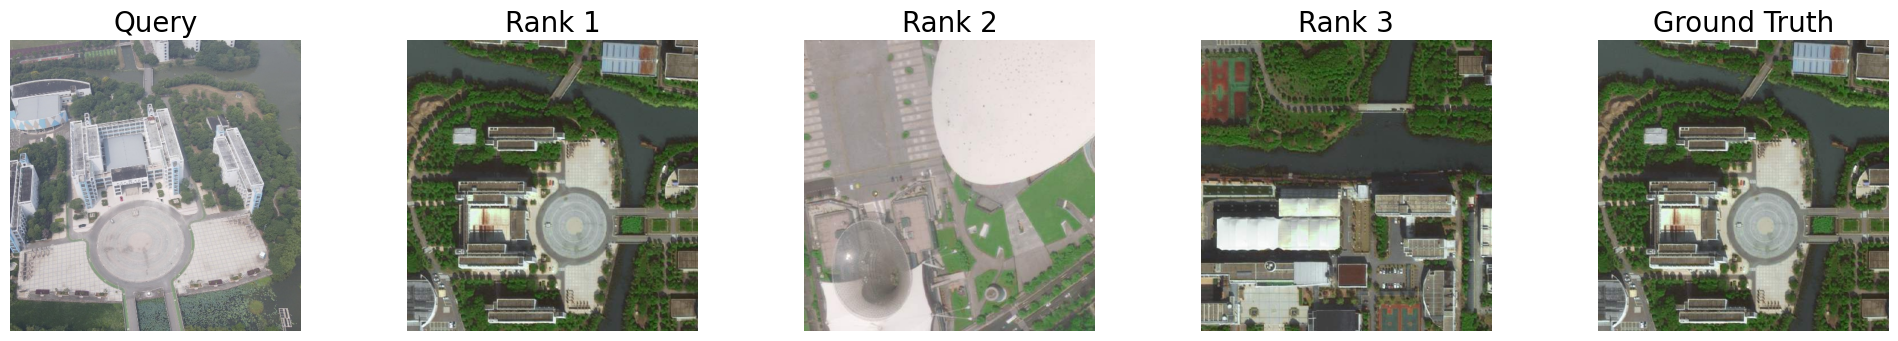

In [32]:
# Visualize retrieval grid for a sample result  
sample_top = sample_top1
if sample_top:
    sample_idx = 1  # Change this index to see different samples
    if len(sample_top) > sample_idx:
        visualize_retrieval_grid(
            model=model,
            image_paths=sample_top[sample_idx], 
            preprocess_fn=val_transforms,
            num_cols=4,  # 1 Query + Top 4 retrievals
            alpha=0.5,
            show_heatmap=False
        )
    else:
        print("Not enough samples in top6_10_list")
else:
    print("No retrieval results loaded. Please load results first.")

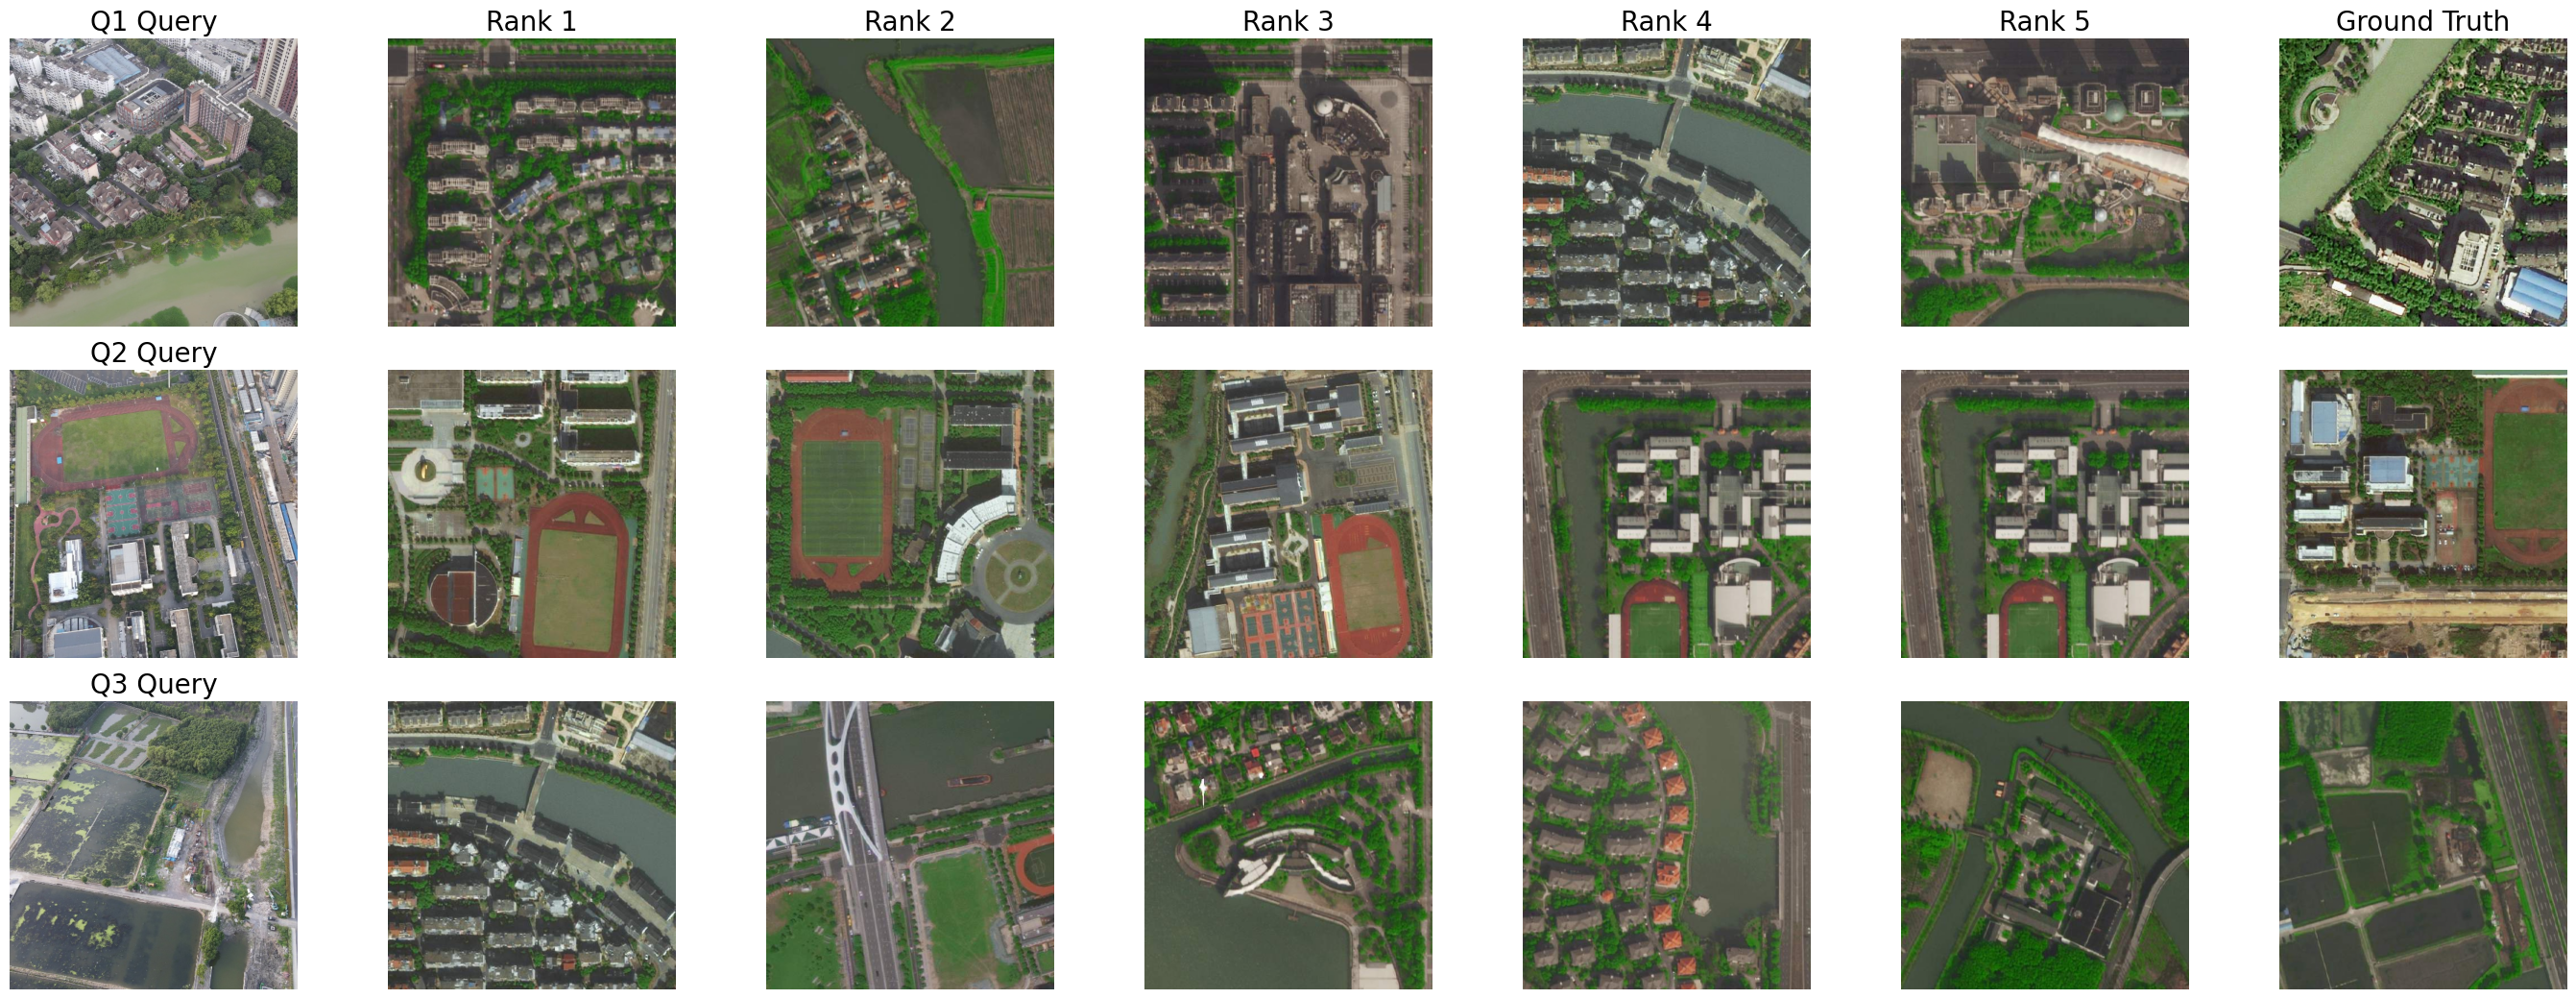

In [18]:
sample_top = sample_outside
if sample_top:
    start_idx = 0
    end_idx = 3
    if len(sample_top) >= (end_idx - start_idx + 1):
        visualize_retrieval_grid_batch(
            model=model,
            batch_image_paths=sample_top[start_idx:end_idx], 
            preprocess_fn=val_transforms,
            num_cols=6,  # 1 Query + Top 4 retrievals
            alpha=0.5,
            show_heatmap=False
        )
    else:
        print("Not enough samples in top6_10_list")
else:
    print("No retrieval results loaded. Please load results first.")